In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix
from src.solvers import AugmentedHybridSDPSolver
from src.plants import AugmentedHybridPlant
from src.controllers import (
    build_approach,
    AugmentedFCLockedControl,
    AugmentedPolicyControl,
    AugmentedValueControl,
)

In [7]:
env = EnvConfig()
config = SimConfig(dP=200, N_Pd = 5)

fleet_data = load_and_cache_entire_fleet(env)
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)


⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 200 kW
 -> Grid Dimensions    : N_d=5, N_n=5, N_soc=19, N_fc=17, N_bat=11
 -> Augmented Space |S|: 8,075 states
 -> Action Space |A|   : 55 actions
 -> Est. Big-O Comput. : O(145,350,000) operations
 -> Est. RAM Footprint : ~46.36 MB

Loading fleet data from binary cache: c:\Users\ext-adam\Desktop\INTERNSHIP\Mariner\opt_power\data\cache\fleet_data_cache.npz
 -> Cache instantly loaded in 0.086 seconds.


In [8]:
augmented_approaches = {
    "MacroFCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "FCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroPolicy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Policy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroValue": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Value": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
}

 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14]...


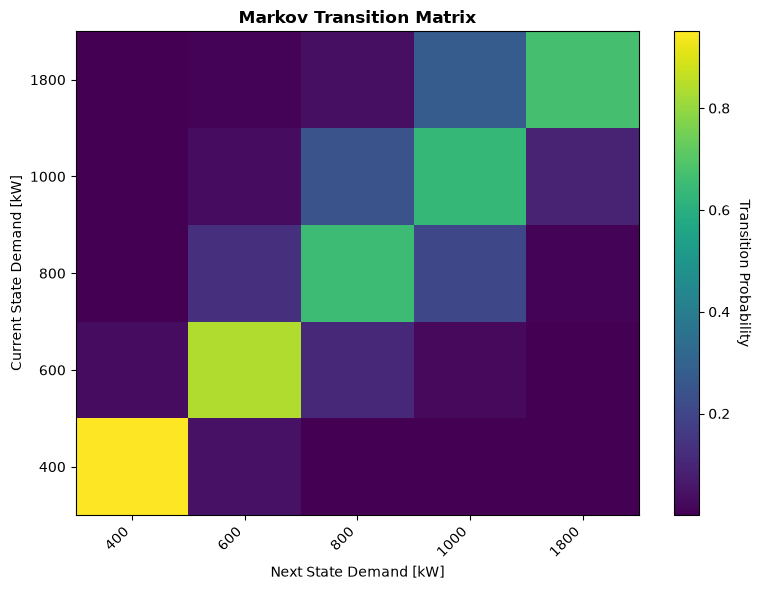

In [9]:
train_days = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
test_day = 6
approaches = augmented_approaches

mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)

--- APPROACH A: HAND-PICKED EVALUATION ---
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
| Strategy      | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| MacroFCLocked | 5408.48        | 5210.95            | 150.53             | 29.27            | 57.28              | 0.00                  | -39.54             | 1.44                     | 0.07                    |
| FCLocked      | 6404.43        | 5255.16            | 86.02              | 38.96            | 1063.84            | 0.00                  | -39.55             | 1.44                     | 0.31                    |
| MacroPolicy   |

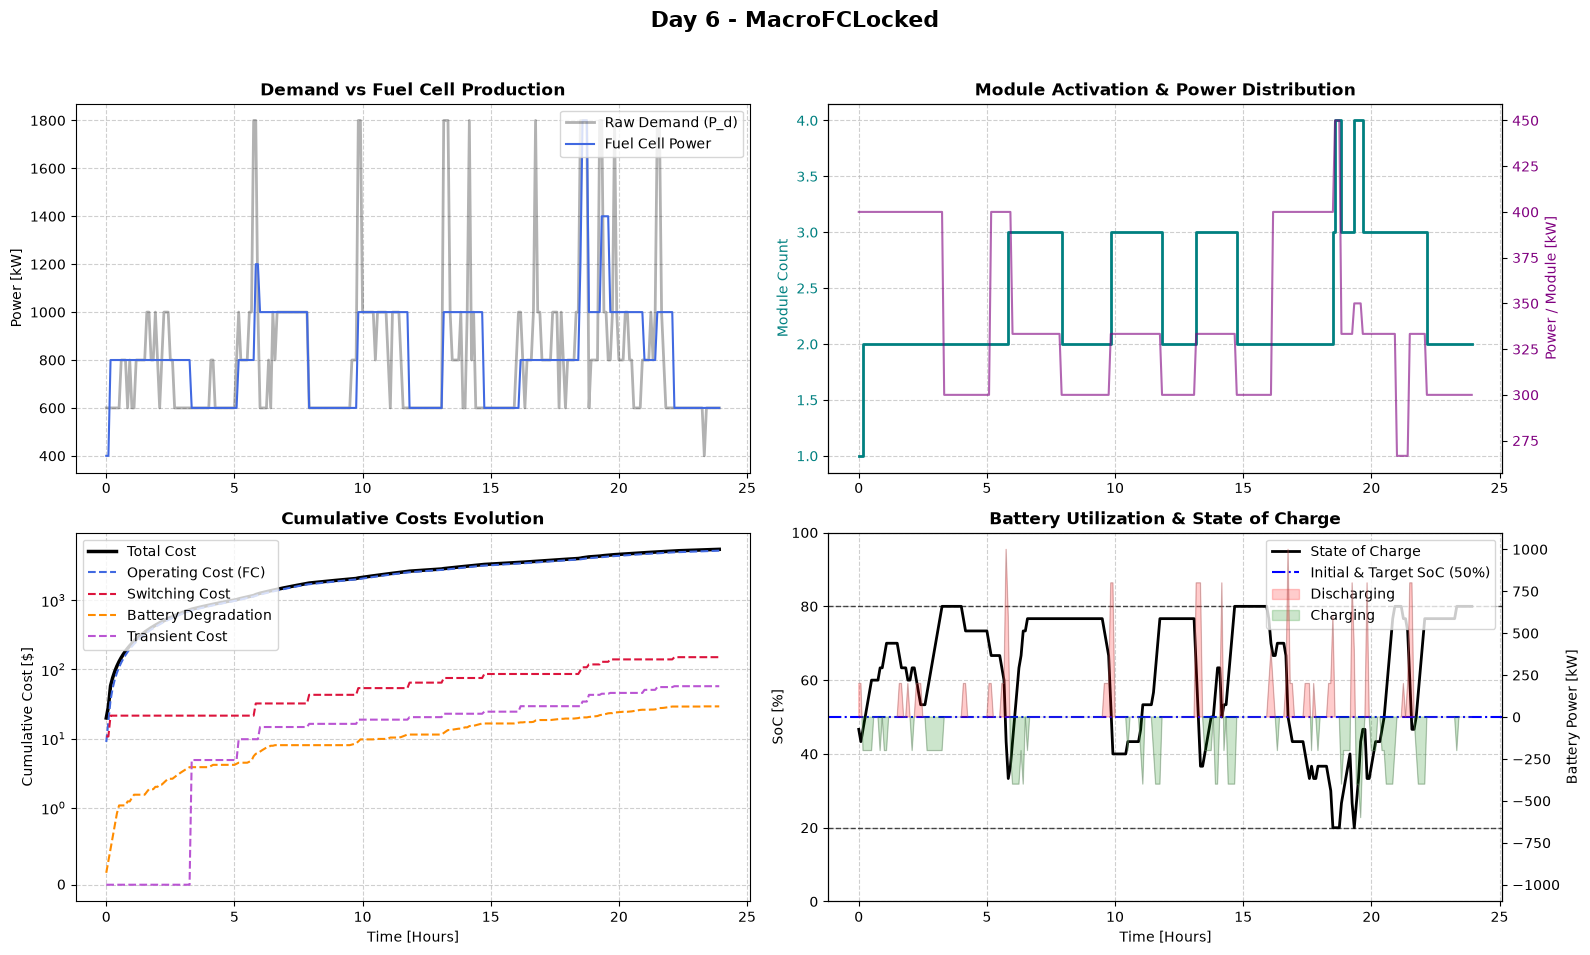

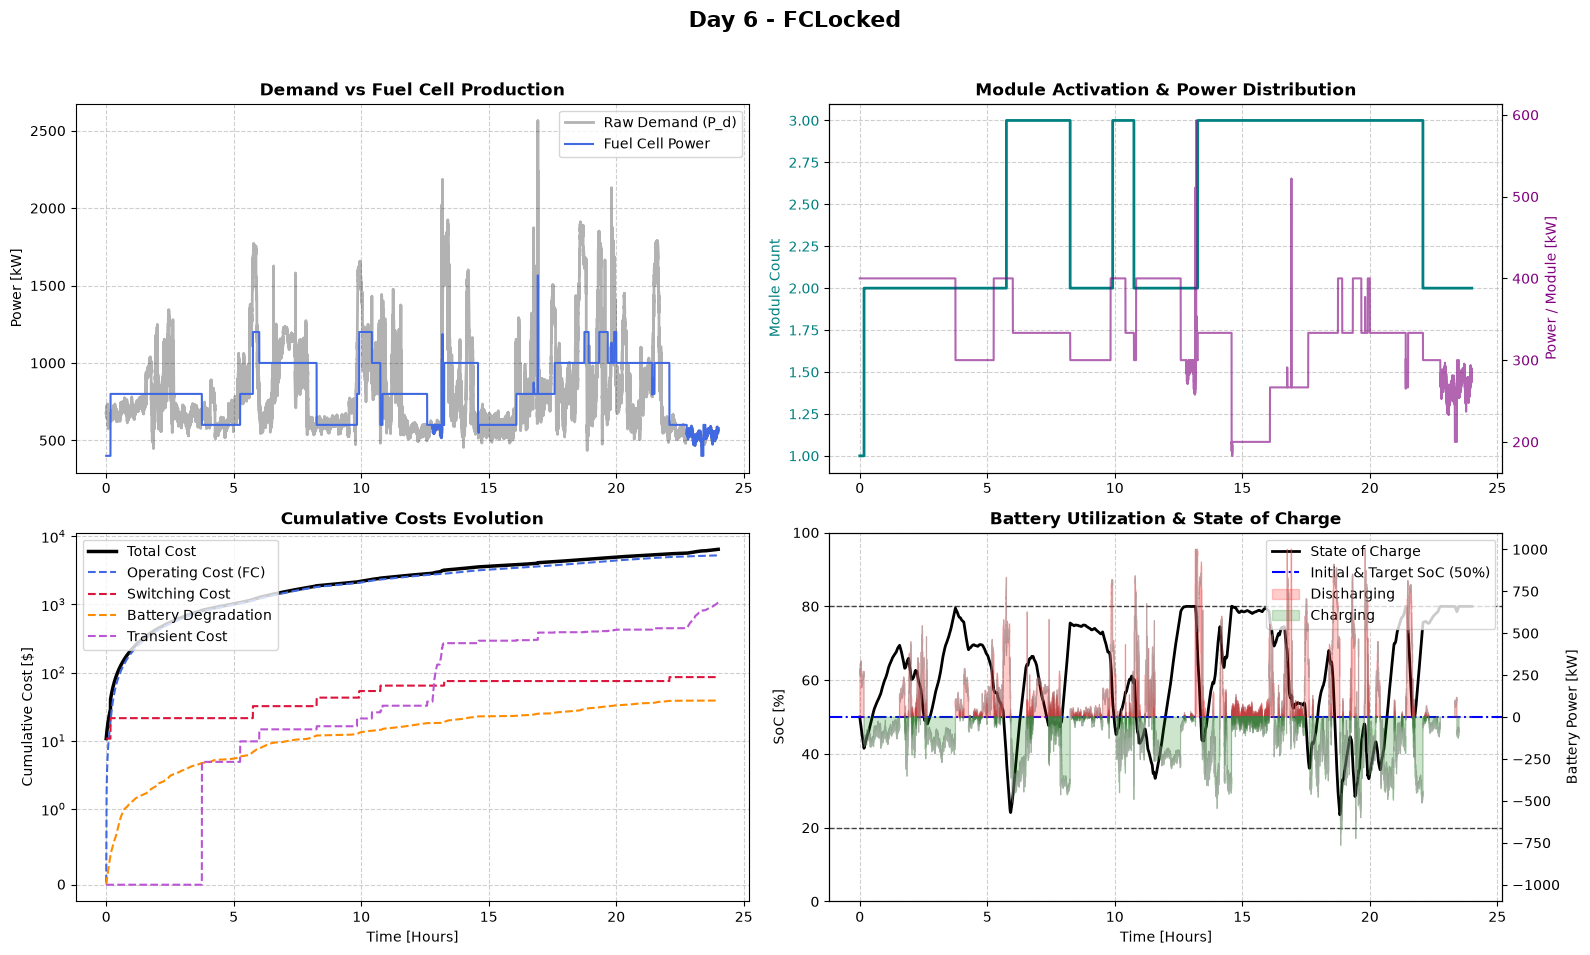

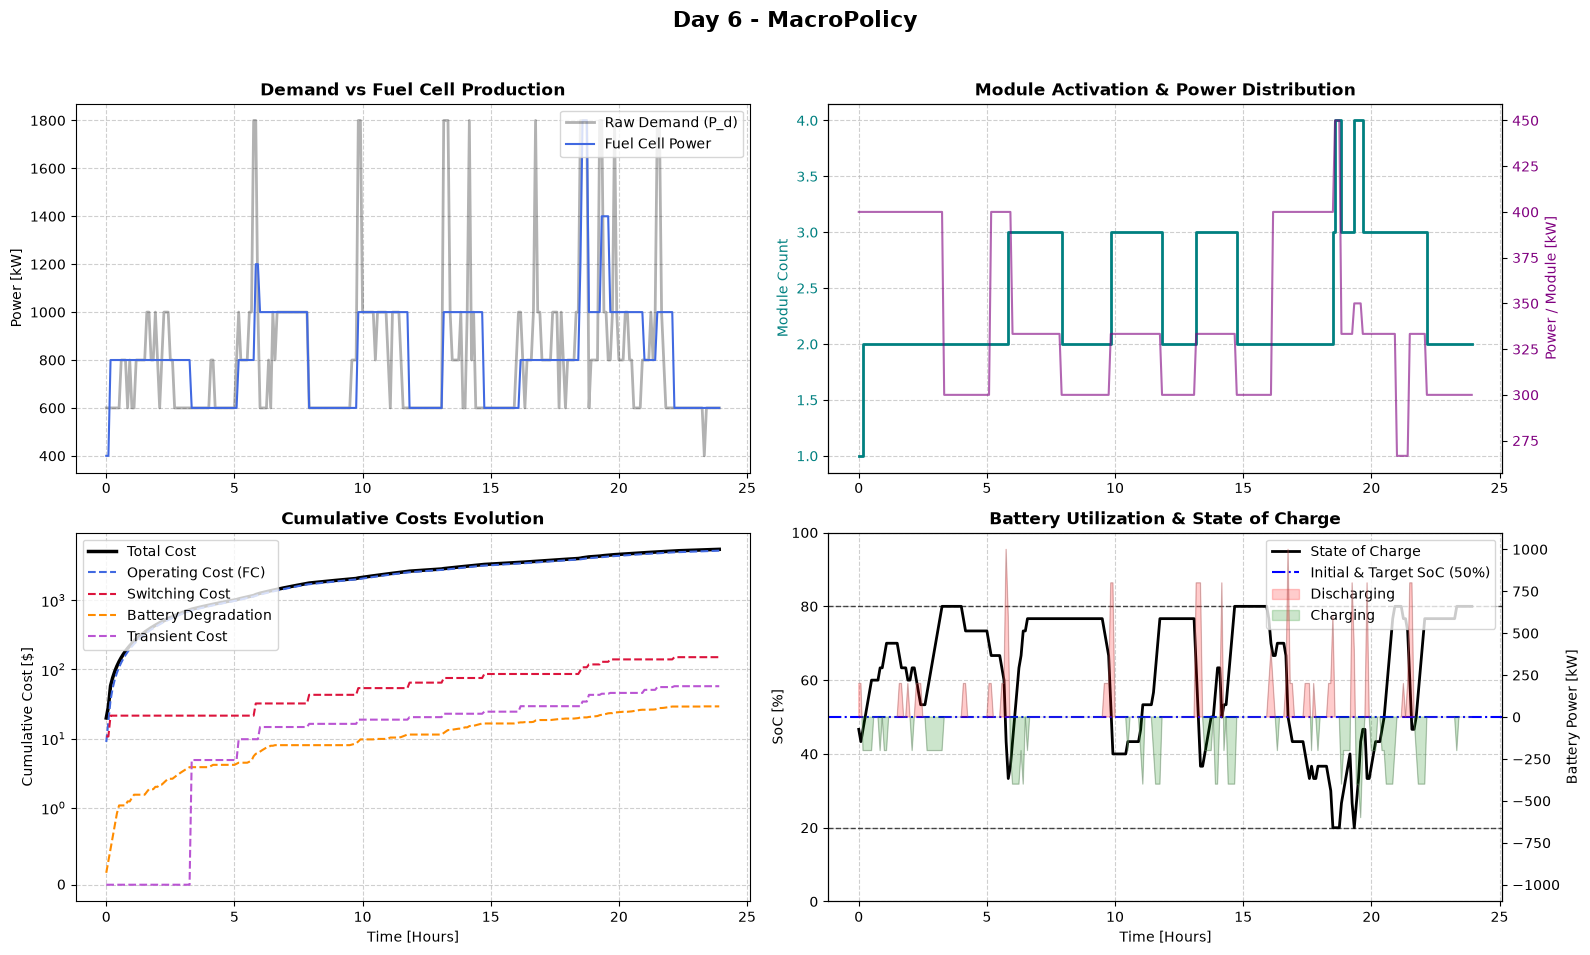

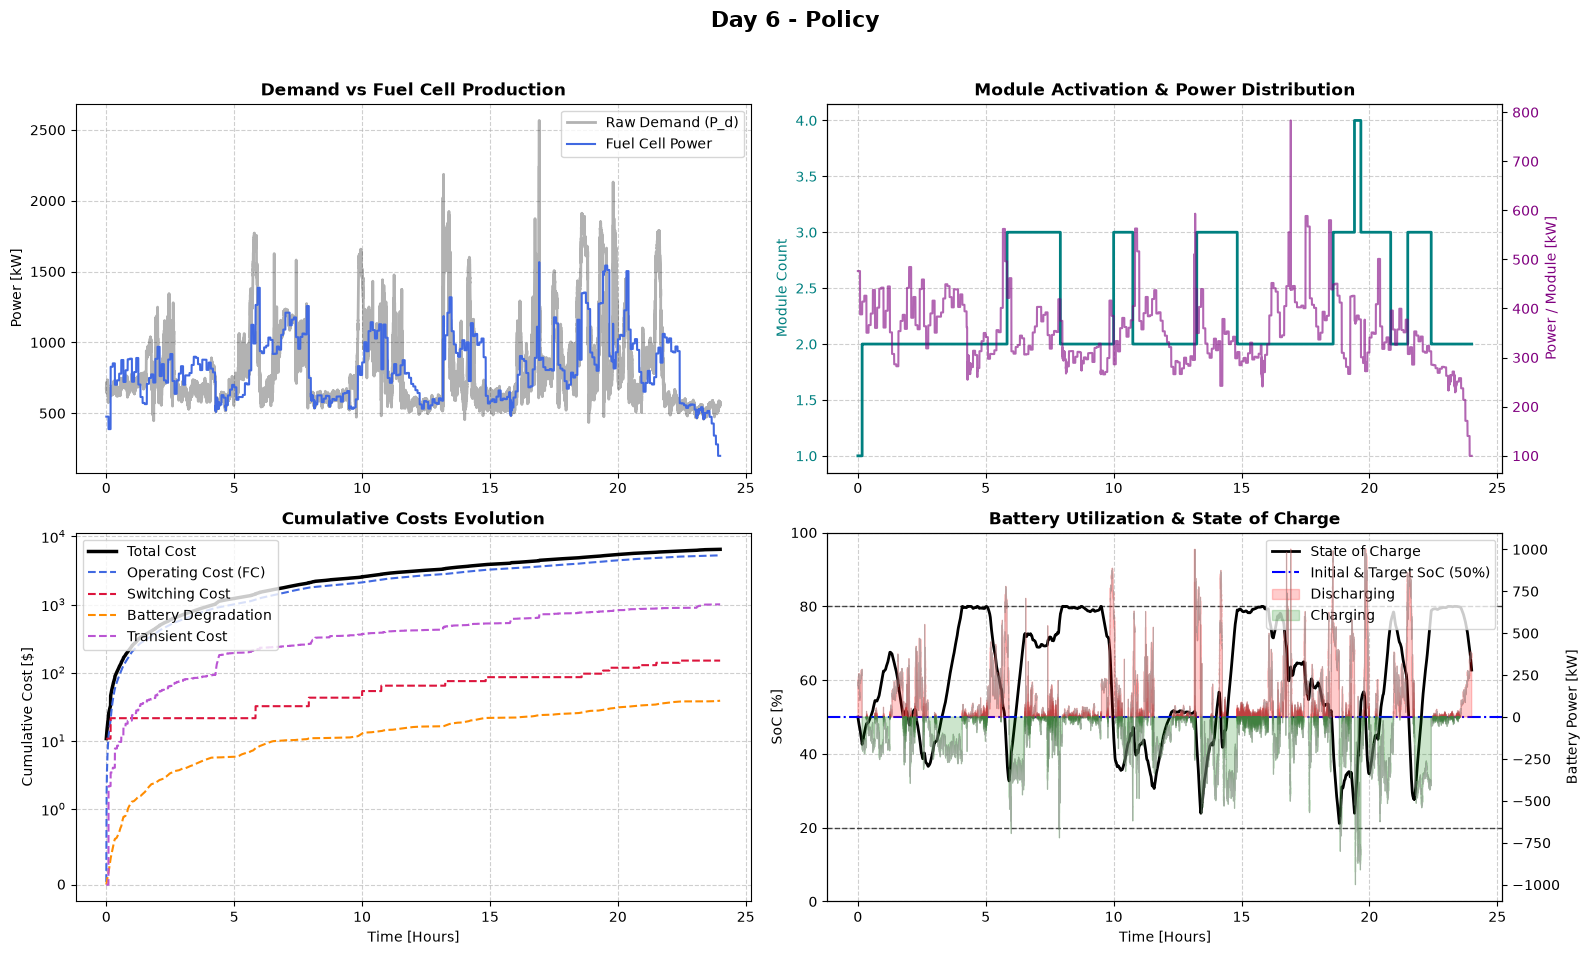

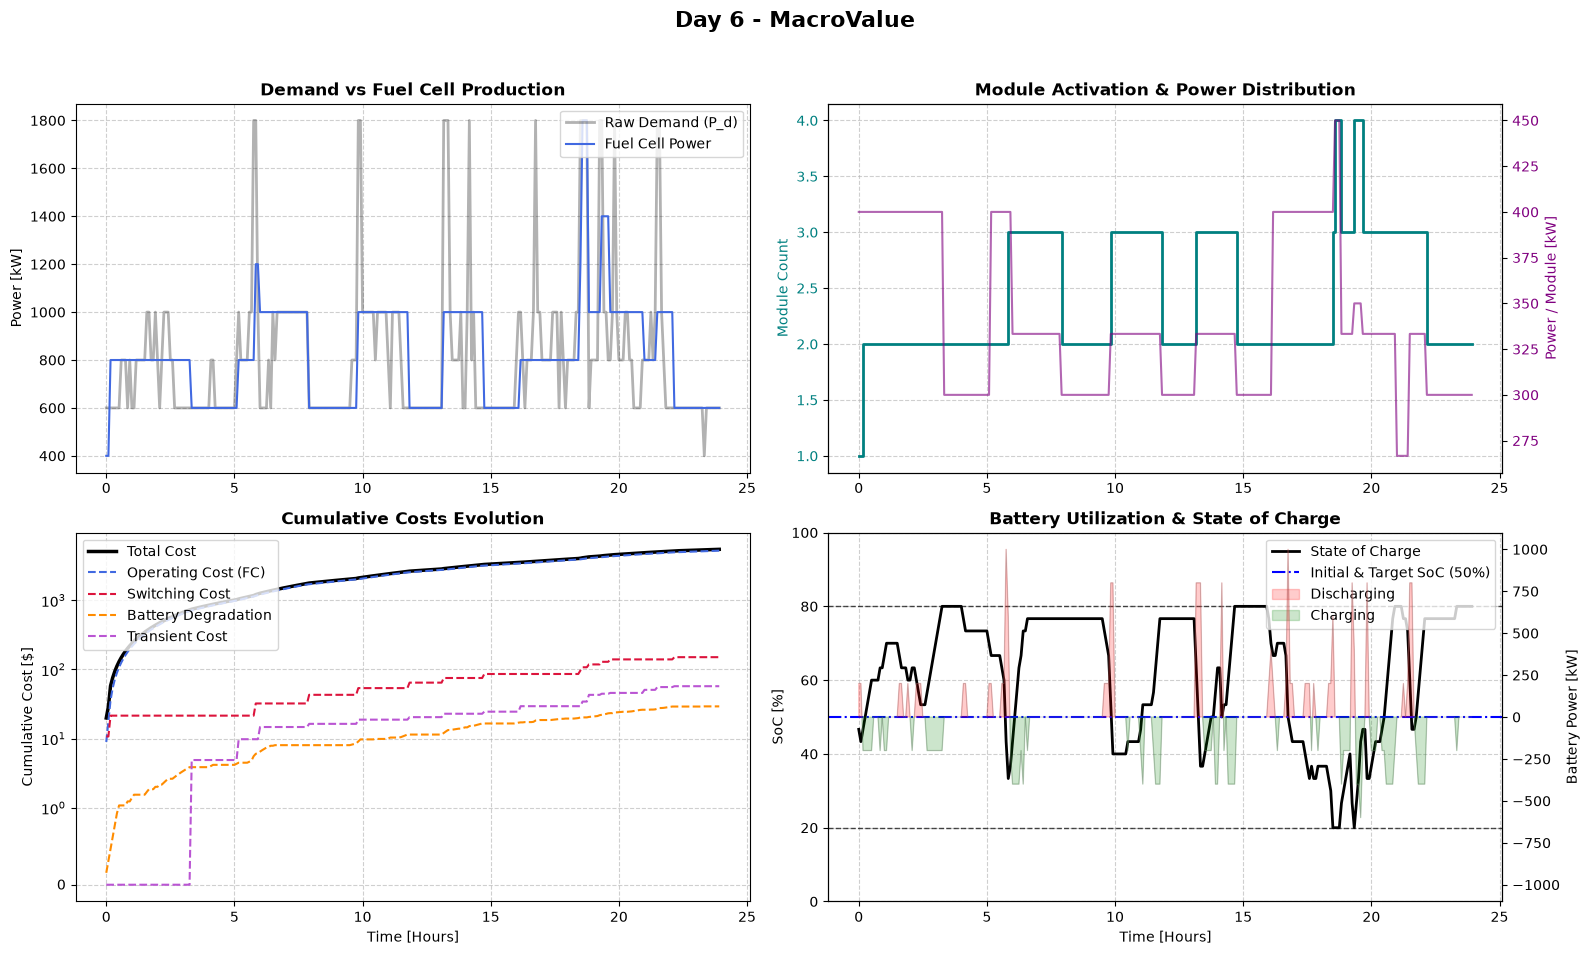

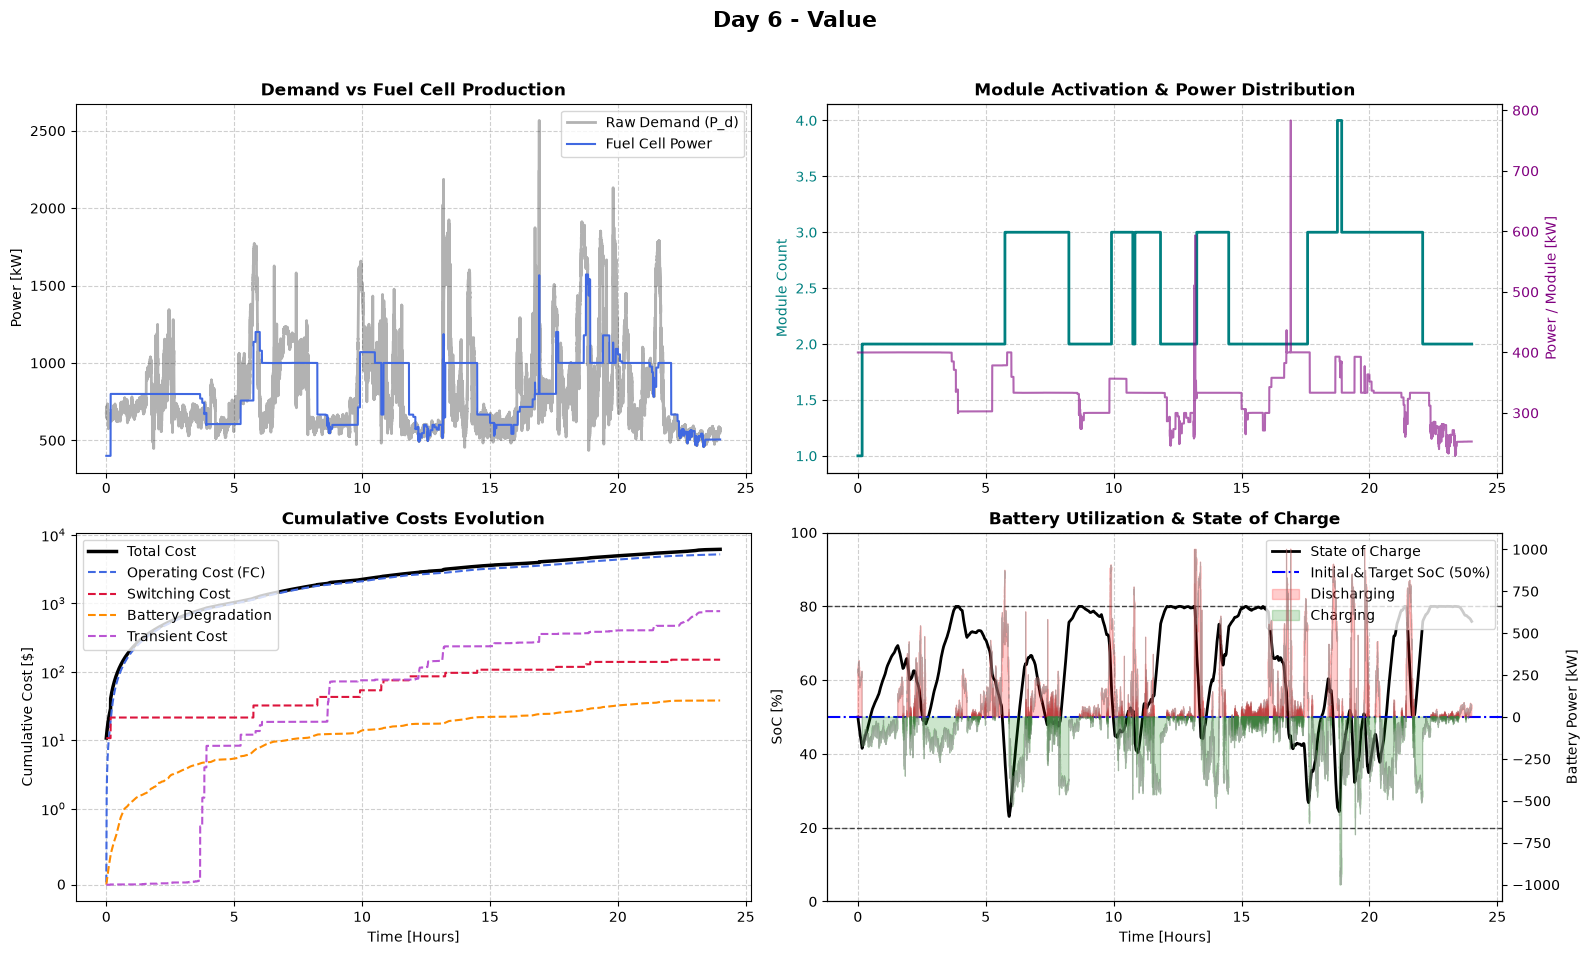

In [10]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)

for app in approaches:
    plot_simulation_dashboard(report.get_telemetry(app), benchmarker.config, title=f"Day {test_day} - {app}", indiv=False)


--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---
 [Vault] Cache MISS: Training Markov Chain for days [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Mar

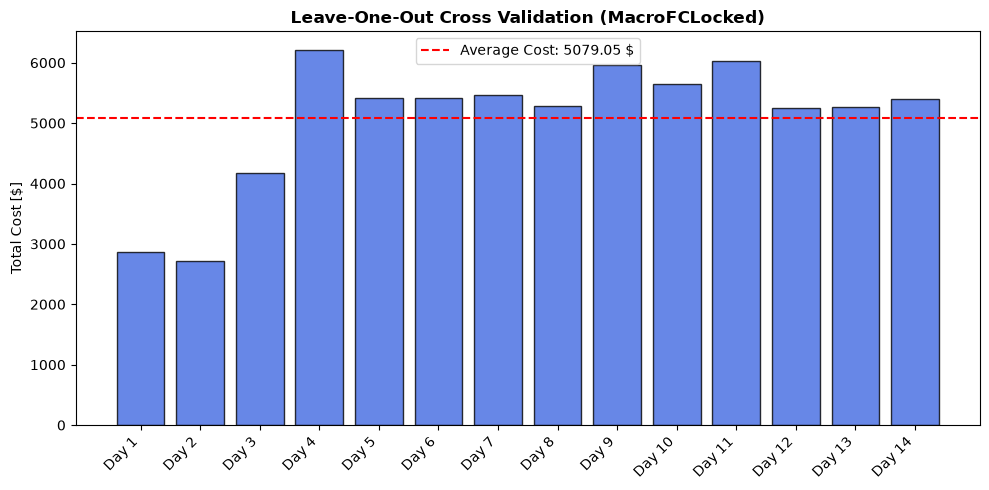

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 2861.75        | 2858.45            | 21.50              | 1.70             | 19.64              | 0.00                  | -39.54             | 1.15                     | 0.00                    |
| Day 2    | 2713.61        | 2720.13            | 21.50              | 1.70             | 9.82               | 0.00                  | -39.54             | 1.09                     | 0.00                    |
| Day 3    | 4176.83        | 4085.75            | 43.01              | 3.10             | 9.82               | 0.00                  | 35.15              | 1.2

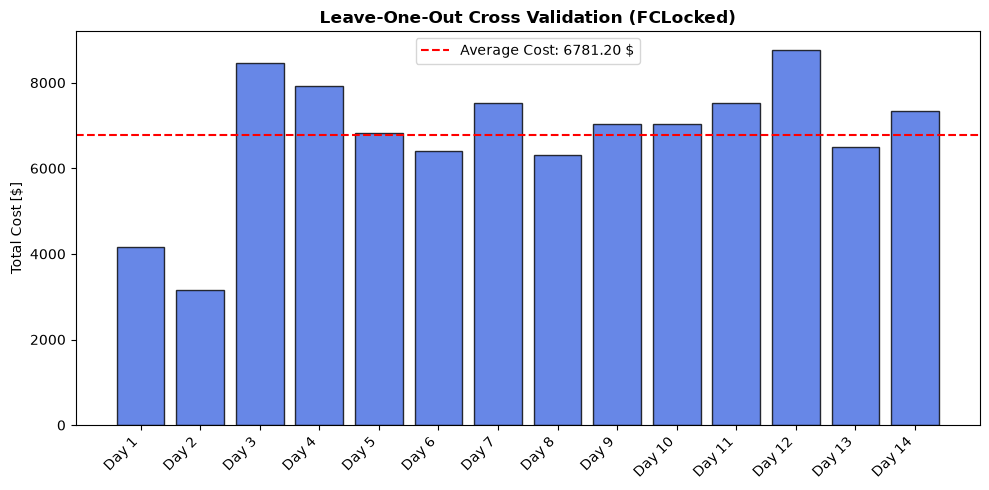

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 4170.36        | 2609.56            | 21.50              | 3.92             | 1572.88            | 0.00                  | -37.50             | 1.15                     | 0.30                    |
| Day 2    | 3146.54        | 2426.81            | 10.75              | 5.79             | 722.54             | 0.00                  | -19.35             | 1.09                     | 0.29                    |
| Day 3    | 8455.44        | 5983.32            | 21.50              | 5.31             | 2405.70            | 0.00                  | 39.61              | 1.2

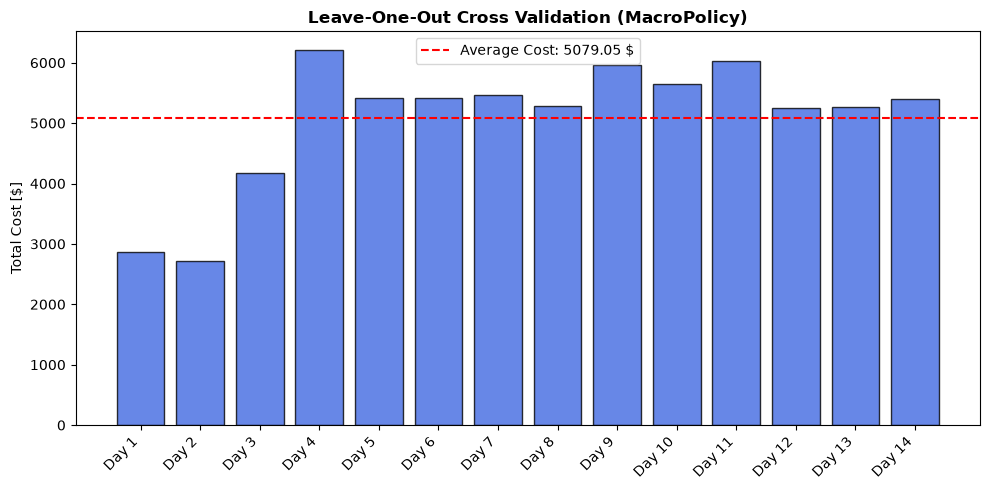

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 2861.75        | 2858.45            | 21.50              | 1.70             | 19.64              | 0.00                  | -39.54             | 1.15                     | 0.00                    |
| Day 2    | 2713.61        | 2720.13            | 21.50              | 1.70             | 9.82               | 0.00                  | -39.54             | 1.09                     | 0.00                    |
| Day 3    | 4176.83        | 4085.75            | 43.01              | 3.10             | 9.82               | 0.00                  | 35.15              | 1.2

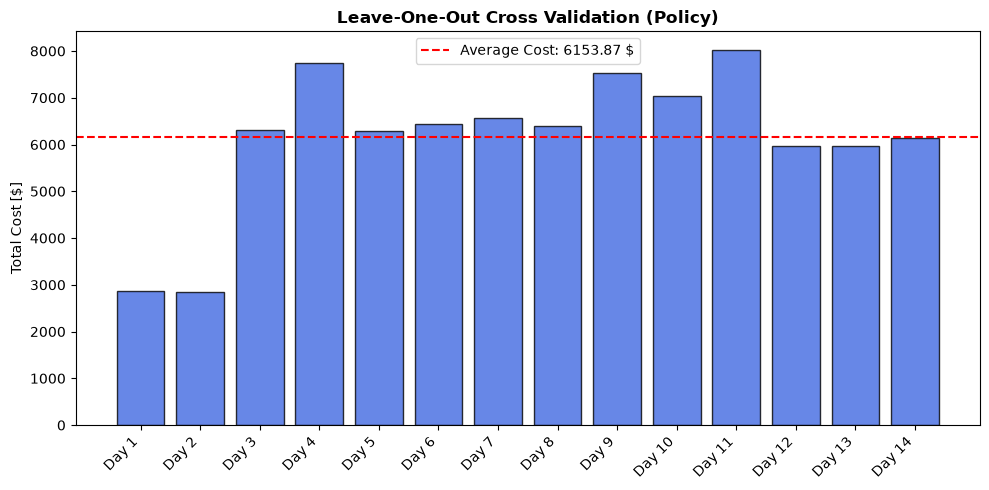

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 2869.38        | 2610.39            | 21.50              | 6.11             | 269.78             | 0.00                  | -38.39             | 1.15                     | 0.30                    |
| Day 2    | 2843.87        | 2599.37            | 21.50              | 5.60             | 253.87             | 0.00                  | -36.48             | 1.09                     | 0.28                    |
| Day 3    | 6312.25        | 5563.47            | 32.26              | 7.21             | 679.64             | 0.00                  | 29.68              | 1.2

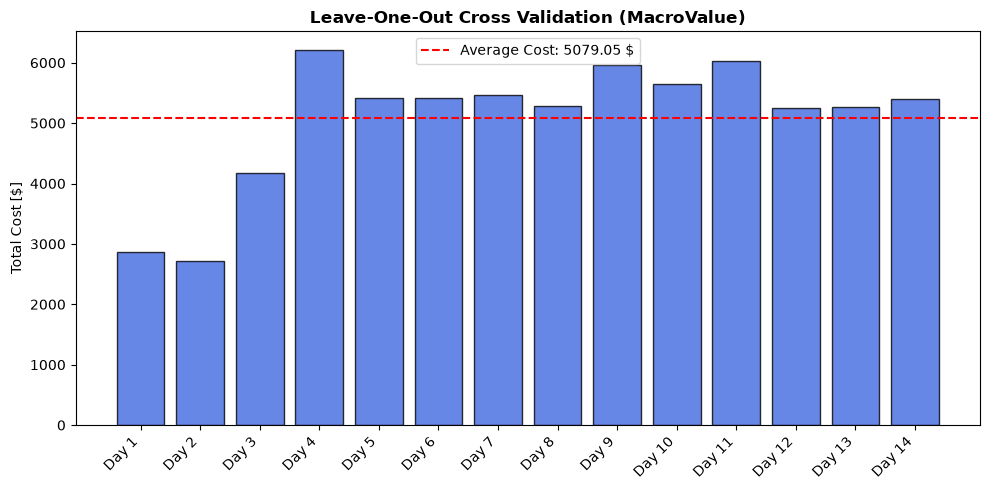

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 2861.75        | 2858.45            | 21.50              | 1.70             | 19.64              | 0.00                  | -39.54             | 1.15                     | 0.00                    |
| Day 2    | 2713.61        | 2720.13            | 21.50              | 1.70             | 9.82               | 0.00                  | -39.54             | 1.09                     | 0.02                    |
| Day 3    | 4176.83        | 4085.75            | 43.01              | 3.10             | 9.82               | 0.00                  | 35.15              | 1.2

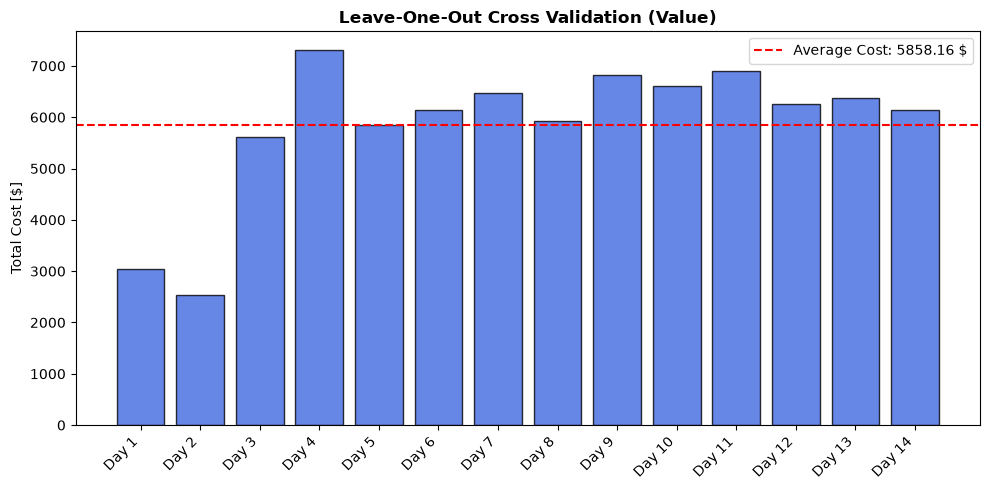

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3042.11        | 2608.77            | 21.50              | 6.37             | 442.53             | 0.00                  | -37.07             | 1.15                     | 0.33                    |
| Day 2    | 2539.47        | 2407.08            | 10.75              | 7.45             | 118.03             | 0.00                  | -3.85              | 1.09                     | 0.28                    |
| Day 3    | 5621.29        | 4660.91            | 64.51              | 7.64             | 849.69             | 0.00                  | 38.54              | 1.2

In [11]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

for app in approaches:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)



In [ ]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 200 #kW
p_nom = 80 #kW
LHV = 120 #kJ/g
eta_max = 0.6
eta_f = 0.5

alpha = p_max / (p_max - p_nom)**2 * (1/eta_f - 1/eta_max)
beta = 1/eta_max - 2*alpha*p_nom 
gamma = alpha * p_nom ** 2

a, b, c = alpha / LHV, beta / LHV, gamma / LHV

p_vec = np.linspace(0, p_max, 100)
plt.plot(p_vec, a*p_vec**2 + b*p_vec + c)
plt.plot(p_vec, p_vec/(a*p_vec**2 + b*p_vec + c)/LHV)